In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

In [3]:
import pandas as pd
df = pd.read_csv("/kaggle/input/datasets/fredericobreno/play-tennis/play_tennis.csv")
df = df.rename(columns={
    "play":"GoOut"
})

df.head()

,day,outlook,temp,humidity,wind,GoOut
0,D1,Sunny,Hot,High,Weak,No
1,D2,Sunny,Hot,High,Strong,No
2,D3,Overcast,Hot,High,Weak,Yes
3,D4,Rain,Mild,High,Weak,Yes
4,D5,Rain,Cool,Normal,Weak,Yes


In [6]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score,confusion_matrix

In [4]:
df = df.drop("day",axis=1)

In [7]:
encoder = LabelEncoder()

for column in df.columns:
    df[column] = encoder.fit_transform(df[column])

df.head()

,outlook,temp,humidity,wind,GoOut
0,2,1,0,1,0
1,2,1,0,0,0
2,0,1,0,1,1
3,1,2,0,1,1
4,1,0,1,1,1


In [8]:
x = df.drop("GoOut",axis=1)
y = df["GoOut"]

In [21]:
X_train,X_test,y_train,y_test  = train_test_split(
    x,y,test_size=0.2,random_state=42
)
model.fit(X_train,y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [19]:
model = DecisionTreeClassifier(
    criterion = "entropy",random_state=42
)

In [22]:
y_pred = model.predict(X_test)

In [23]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix")
print(confusion_matrix(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix
[[1 0]
 [0 2]]


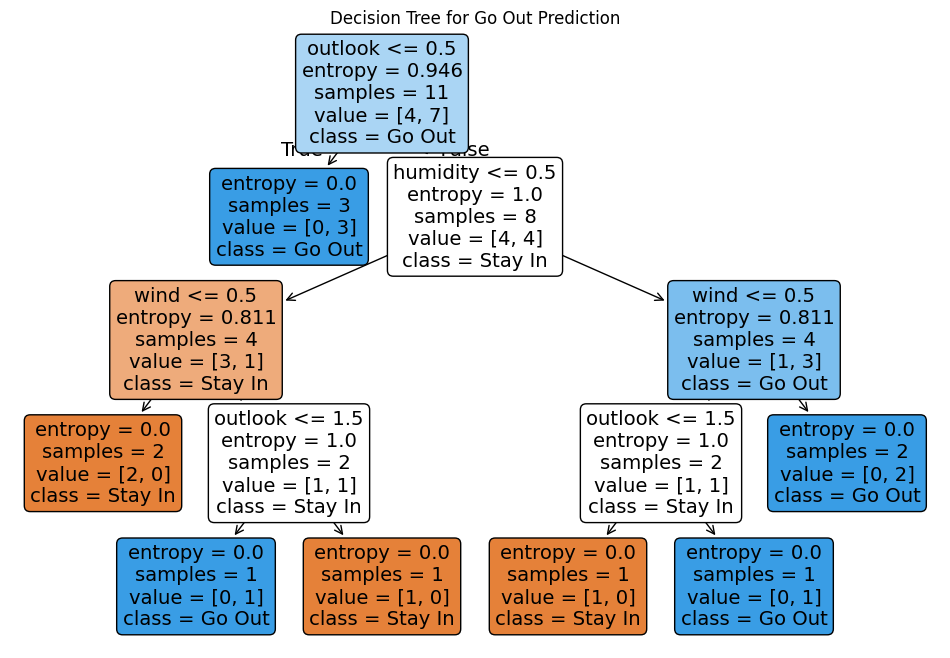

In [25]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

plt.figure(figsize=(12, 8))

plot_tree(
    model,
    feature_names=x.columns,
    class_names=["Stay In", "Go Out"],
    filled=True,
    rounded=True
)

plt.title("Decision Tree for Go Out Prediction")
plt.show()